In [1]:
# o build a classification algorithm using ANN for different datasets and obtain confusion matrix, accuracy and loss curves from the model generated.

In [1]:
import pandas as pd

seed_data = "datasets/seeds_dataset.txt"

column_names = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "groove_length",
    "class"
]

# FIXED: raw string for separator
data = pd.read_csv(seed_data, sep=r'\s+', names=column_names)

data.head()


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [2]:
# Understanding the dataset
print("The information about the dataset:", data.info())
print("\nThe statistical summary of the dataset:", data.describe())
print("\nThe number of samples in each class:", data['class'].value_counts())
print("\nThe column names in the dataset:", data.columns)
print("\nThe shape of the dataset:", data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   kernel_length          210 non-null    float64
 4   kernel_width           210 non-null    float64
 5   asymmetry_coefficient  210 non-null    float64
 6   groove_length          210 non-null    float64
 7   class                  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB
The information about the dataset: None

The statistical summary of the dataset:              area   perimeter  compactness  kernel_length  kernel_width  \
count  210.000000  210.000000   210.000000     210.000000    210.000000   
mean    14.847524   14.559286     0.870999       5.628533      3.258605   
std      2.909699  

In [3]:
# Handle missing values and normalize/standardize features if necessary
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data.drop("class", axis=1)
y = data["class"]

# Handle missing values (mean strategy)
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Convert back to DataFrame (optional but useful)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Quick check
print("Missing values after imputation:")
print(X_scaled.isnull().sum())

X_scaled.head()


Missing values after imputation:
area                     0
perimeter                0
compactness              0
kernel_length            0
kernel_width             0
asymmetry_coefficient    0
groove_length            0
dtype: int64


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356


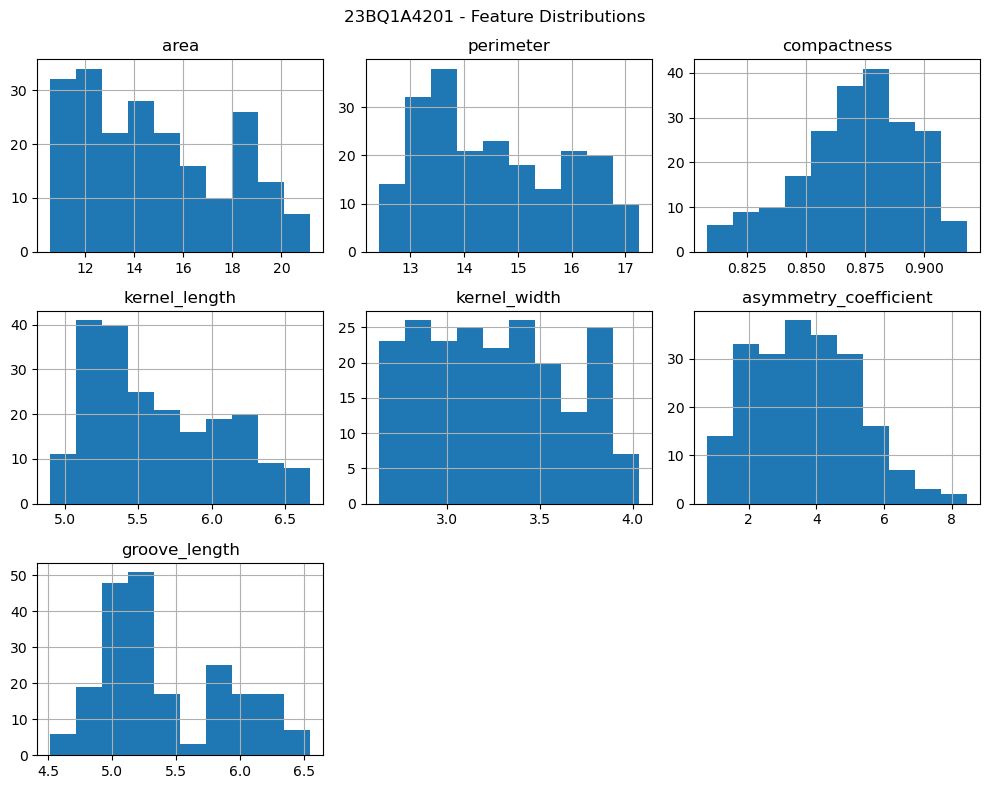

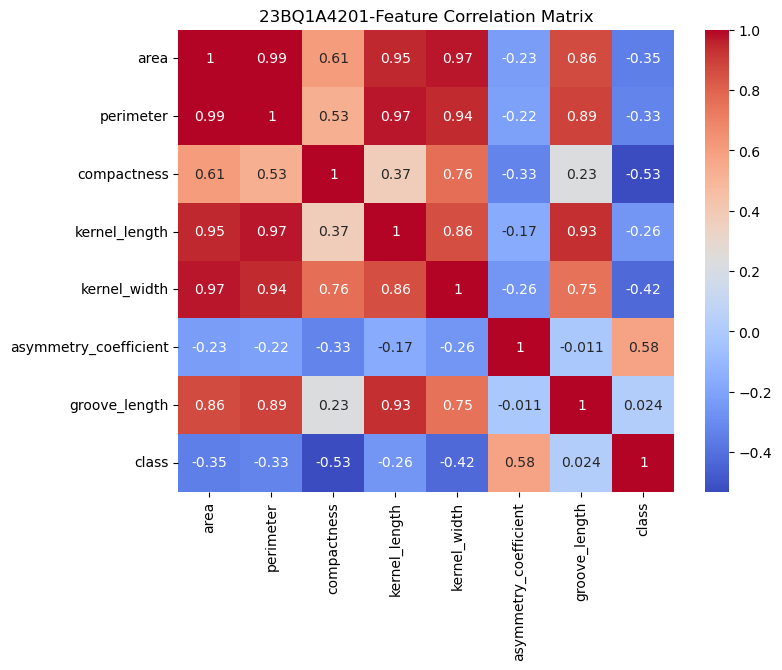

In [7]:
#  Perform exploratory data analysis (EDA) to understand the distribution and characteristics of the data. 
import matplotlib.pyplot as plt
import seaborn as sns

# Feature distribution histograms
data.drop("class", axis=1).hist(figsize=(10, 8))
plt.suptitle("23BQ1A4201 - Feature Distributions")
plt.tight_layout()
plt.show()

# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("23BQ1A4201-Feature Correlation Matrix")
plt.show()



In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Convert class labels to one-hot encoding
y_train_cat = to_categorical(y_train - 1)  # classes are 1,2,3
y_test_cat = to_categorical(y_test - 1)

# -----------------------------
# Hyperparameters (EASY TO TUNE)
# -----------------------------
hidden_layers = [64, 32]        # neurons per hidden layer
activation_fn = "relu"
dropout_rate = 0.3
learning_rate = 0.001
batch_size = 16
epochs = 100

In [9]:
from tensorflow.keras.layers import Dense, Dropout, Input
# -----------------------------
# Build Model (Correct Version)
# -----------------------------
model = Sequential()

# Explicit Input Layer (Recommended)
model.add(Input(shape=(X_train.shape[1],)))

# First Hidden Layer
model.add(Dense(hidden_layers[0], activation=activation_fn))
model.add(Dropout(dropout_rate))

# Additional Hidden Layers
for neurons in hidden_layers[1:]:
    model.add(Dense(neurons, activation=activation_fn))
    model.add(Dropout(dropout_rate))

# Output Layer (3 classes)
model.add(Dense(3, activation="softmax"))

# Optimizer
optimizer = Adam(learning_rate=learning_rate)

In [10]:
# Compile
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5299 - loss: 0.9394 - val_accuracy: 0.7647 - val_loss: 0.7476
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6045 - loss: 0.8356 - val_accuracy: 0.7941 - val_loss: 0.6273
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7090 - loss: 0.6811 - val_accuracy: 0.8235 - val_loss: 0.5397
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7612 - loss: 0.6178 - val_accuracy: 0.8235 - val_loss: 0.4695
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8209 - loss: 0.5316 - val_accuracy: 0.8529 - val_loss: 0.4179
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8284 - loss: 0.5052 - val_accuracy: 0.8824 - val_loss: 0.3733
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8881 - loss: 0.4289 - val_accuracy: 0.8824 - val_loss: 0.3358
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8881 - loss: 0.3996 - val_accuracy: 0.8824 - val_loss: 0.

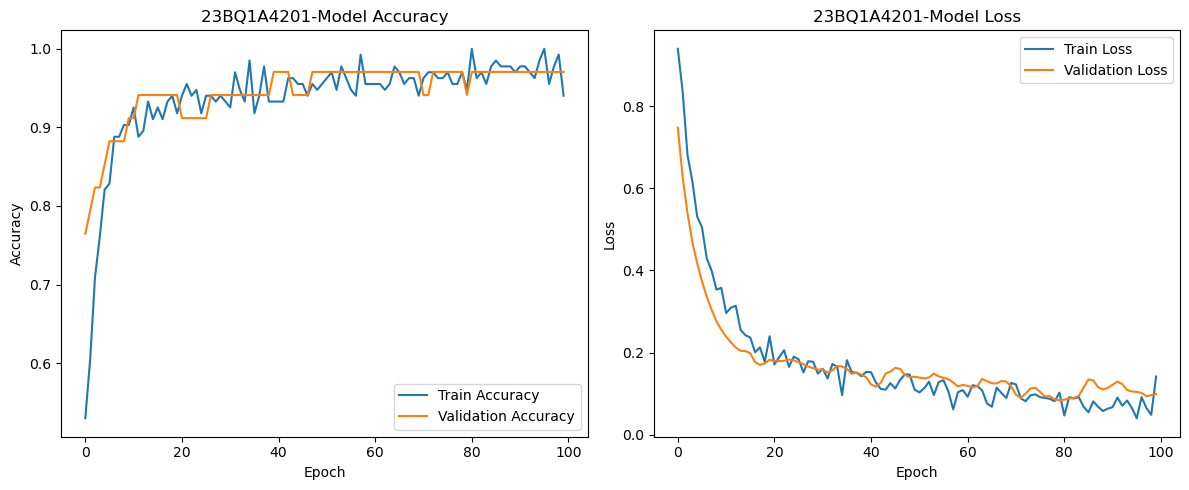

In [13]:
# plot training history and validation history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('23BQ1A4201-Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('23BQ1A4201-Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Accuracy: 0.8809523809523809

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.64      0.78        14
           1       0.88      1.00      0.93        14
           2       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42



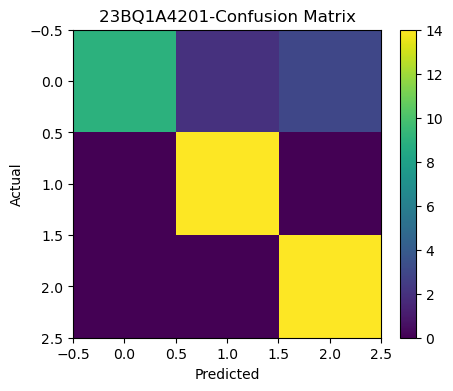

In [31]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# -----------------------------
# Predictions
# -----------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# -----------------------------
# Accuracy + Precision + Recall + F1
# -----------------------------
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("23BQ1A4201-Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [15]:
import numpy as np
import pandas as pd

# ==============================
# 1. Predict on Test Data
# ==============================

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels (0,1,2)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded true labels
y_true = np.argmax(y_test_cat, axis=1)

# Display first 10 predictions
print("First 10 Predictions:")
for i in range(10):
    print(f"Actual: {y_true[i] + 1}  |  Predicted: {y_pred[i] + 1}")

# ==============================
# 2. Create Results DataFrame
# ==============================

results = pd.DataFrame({
    "Actual_Class": y_true + 1,
    "Predicted_Class": y_pred + 1
})

print("\nFirst 15 Results:")
print(results.head(15))

# ==============================
# 3. Predict on New Sample
# ==============================

new_sample = np.array([[
    15.5,   # area
    14.8,   # perimeter
    0.88,   # compactness
    5.7,    # kernel_length
    3.4,    # kernel_width
    2.0,    # asymmetry
    5.1     # groove_length
]])

# Standardize using same scaler
new_sample_scaled = scaler.transform(new_sample)

# Predict
prediction = model.predict(new_sample_scaled)
predicted_class = np.argmax(prediction, axis=1)[0] + 1

print("\nPredicted Seed Class for New Sample:", predicted_class)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
First 10 Predictions:
Actual: 1  |  Predicted: 1
Actual: 3  |  Predicted: 3
Actual: 2  |  Predicted: 2
Actual: 3  |  Predicted: 3
Actual: 2  |  Predicted: 2
Actual: 3  |  Predicted: 3
Actual: 2  |  Predicted: 2
Actual: 1  |  Predicted: 1
Actual: 2  |  Predicted: 2
Actual: 2  |  Predicted: 2

First 15 Results:
    Actual_Class  Predicted_Class
0              1                1
1              3                3
2              2                2
3              3                3
4              2                2
5              3                3
6              2                2
7              1                1
8              2                2
9              2                2
10             1                3
11             3                3
12             2                2
13             2                2
14             3                3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Predicted Seed Class for New Sample: 1


In [16]:
# Glass Dataset
import pandas as pd

file_path = "datasets/glass.data"

column_names = [
    "Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"
]

glass_data = pd.read_csv(file_path, header=None, names=column_names)

# Drop the ID column as it is not a predictor
glass_data = glass_data.drop("Id", axis=1)

glass_data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [17]:
# Preprocess
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Separate features & target
X_glass = glass_data.drop("Type", axis=1)
y_glass = glass_data["Type"]

# Impute missing values (though none should exist in this dataset)
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_glass)

# Standardize numeric features
scaler = StandardScaler()
X_scaled_glass = scaler.fit_transform(X_imputed)

# Convert back to DataFrame (optional)
X_scaled_glass = pd.DataFrame(X_scaled_glass, columns=X_glass.columns)


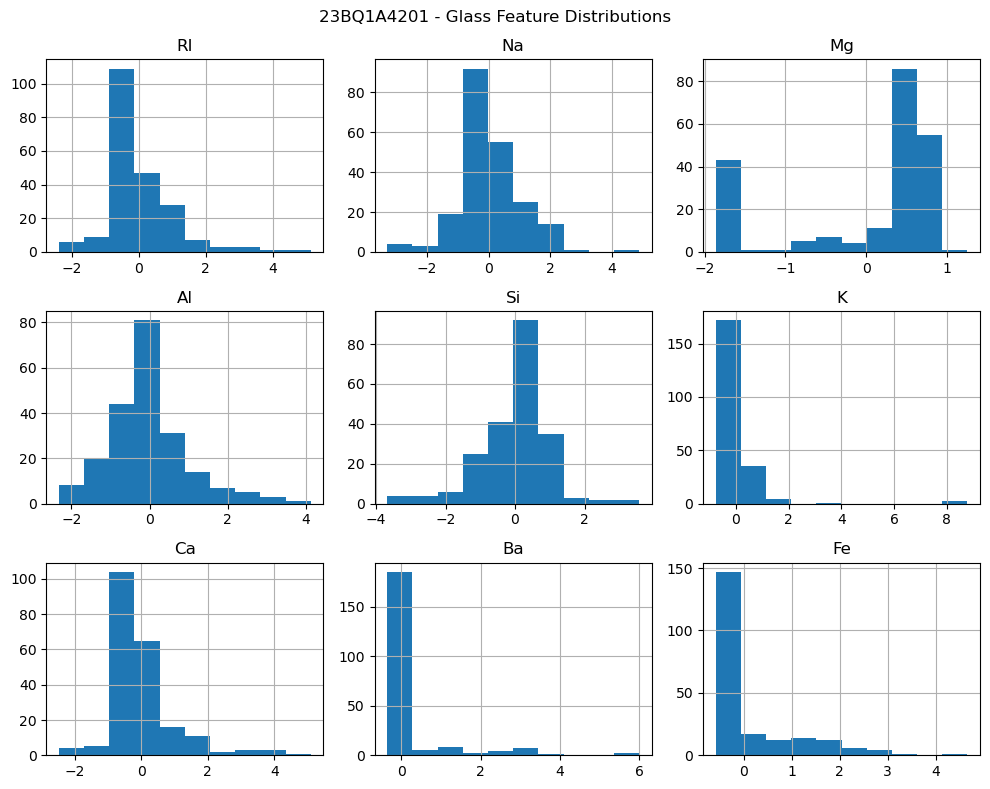

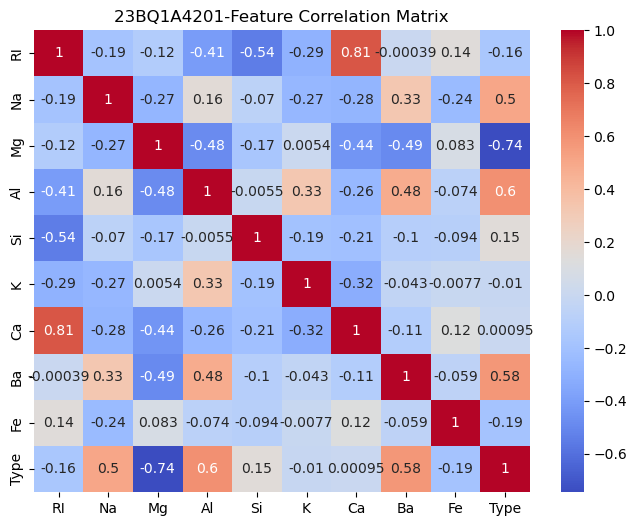

In [21]:
import matplotlib.pyplot as plt

X_scaled_glass.hist(figsize=(10, 8))
plt.suptitle("23BQ1A4201 - Glass Feature Distributions")
plt.tight_layout()
plt.show()


# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(glass_data.corr(), annot=True, cmap="coolwarm")
plt.title("23BQ1A4201-Feature Correlation Matrix")
plt.show()


In [22]:
# Train/Test Split & Encoding
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_scaled_glass, y_glass, test_size=0.2, random_state=42, stratify=y_glass
)

y_train_cat_g = to_categorical(y_train_g - 1)
y_test_cat_g = to_categorical(y_test_g - 1)


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

model_glass = Sequential([
    Input(shape=(X_train_g.shape[1],)),   # Proper Input layer
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(y_test_cat_g.shape[1], activation="softmax")
])

In [24]:
model_glass.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
history_glass = model_glass.fit(
    X_train_g, y_train_cat_g,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2647 - loss: 1.9335 - val_accuracy: 0.4000 - val_loss: 1.8144
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3235 - loss: 1.8814 - val_accuracy: 0.4000 - val_loss: 1.7686
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3456 - loss: 1.7223 - val_accuracy: 0.4571 - val_loss: 1.7294
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4191 - loss: 1.5908 - val_accuracy: 0.4571 - val_loss: 1.6971
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3971 - loss: 1.5517 - val_accuracy: 0.5143 - val_loss: 1.6648
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4485 - loss: 1.4816 - val_accuracy: 0.4857 - val_loss: 1.6376
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4926 - loss: 1.3806 - val_accuracy: 0.4571 - val_loss: 1.6160
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4926 - loss: 1.3064 - val_accuracy: 0.4286 - val_loss:

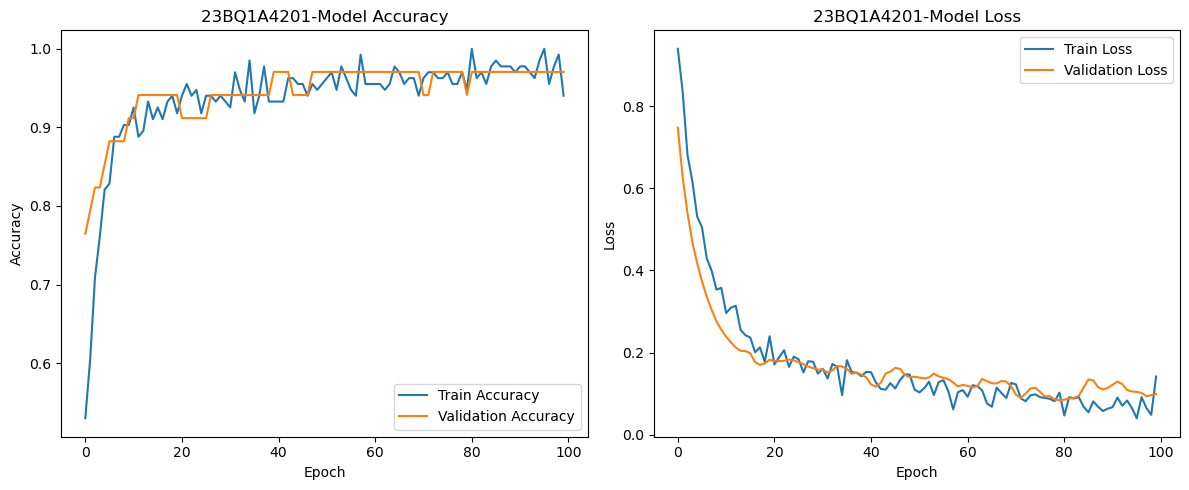

In [25]:
# plot training history and validation history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('23BQ1A4201-Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('23BQ1A4201-Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Accuracy: 0.11627906976744186

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.29      0.36        14
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         0
           4       0.08      0.33      0.12         3
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         6

    accuracy                           0.12        43
   macro avg       0.08      0.09      0.07        43
weighted avg       0.17      0.12      0.13        43



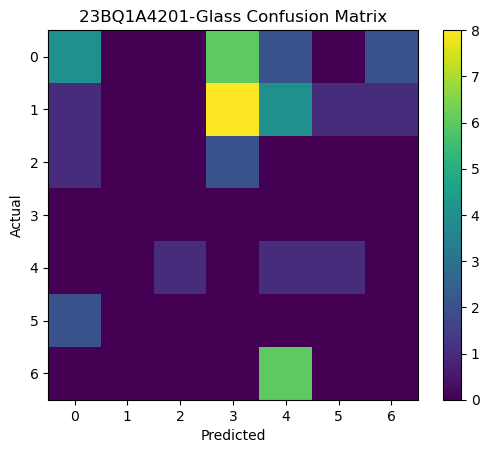

In [32]:
# -----------------------------
# Evaluation (Accuracy, Report, Confusion Matrix)
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred_probs_g = model_glass.predict(X_test_g)
y_pred_g = np.argmax(y_pred_probs_g, axis=1)
y_true_g = np.argmax(y_test_cat_g, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true_g, y_pred_g))

# Classification Report (Fixed Warning)
print("\nClassification Report:")
print(classification_report(y_true_g, y_pred_g, zero_division=0))

# Confusion Matrix
cm_g = confusion_matrix(y_true_g, y_pred_g)

plt.figure()
plt.imshow(cm_g)
plt.colorbar()
plt.title("23BQ1A4201-Glass Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [27]:
# ==============================
# Glass Model Predictions
# ==============================

import numpy as np
import pandas as pd

# 1️⃣ Predict on Test Data
y_pred_probs_g = model_glass.predict(X_test_g)

# Convert probabilities → class labels (0-based)
y_pred_g = np.argmax(y_pred_probs_g, axis=1)

# Convert true labels (from one-hot)
y_true_g = np.argmax(y_test_cat_g, axis=1)

# Display first 10 predictions
print("First 10 Glass Predictions:")
for i in range(10):
    print(f"Actual: {y_true_g[i] + 1}  |  Predicted: {y_pred_g[i] + 1}")

# 2️⃣ Create Results DataFrame
results_glass = pd.DataFrame({
    "Actual_Type": y_true_g + 1,
    "Predicted_Type": y_pred_g + 1
})

print("\nFirst 15 Results:")
print(results_glass.head(15))

# 3️⃣ Predict on New Glass Sample
new_glass_sample = np.array([[
    1.52101,  # RI
    13.64,    # Na
    4.49,     # Mg
    1.10,     # Al
    71.78,    # Si
    0.06,     # K
    8.75,     # Ca
    0.00,     # Ba
    0.00      # Fe
]])

# Scale using SAME scaler used for training
new_glass_scaled = scaler.transform(new_glass_sample)

# Predict
prediction_g = model_glass.predict(new_glass_scaled)
predicted_type = np.argmax(prediction_g, axis=1)[0] + 1

print("\nPredicted Glass Type for New Sample:", predicted_type)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
First 10 Glass Predictions:
Actual: 7  |  Predicted: 5
Actual: 5  |  Predicted: 5
Actual: 2  |  Predicted: 4
Actual: 5  |  Predicted: 6
Actual: 1  |  Predicted: 4
Actual: 1  |  Predicted: 4
Actual: 2  |  Predicted: 4
Actual: 2  |  Predicted: 6
Actual: 1  |  Predicted: 5
Actual: 1  |  Predicted: 1

First 15 Results:
    Actual_Type  Predicted_Type
0             7               5
1             5               5
2             2               4
3             5               6
4             1               4
5             1               4
6             2               4
7             2               6
8             1               5
9             1               1
10            3               4
11            1               5
12            7               5
13            6               1
14            2               7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Predicted Glass Type for New Sample: 5


In [28]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

# ==============================
# Seeds Metrics
# ==============================

acc_seeds = accuracy_score(y_true, y_pred)

prec_s, rec_s, f1_s, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# ==============================
# Glass Metrics
# ==============================

acc_glass = accuracy_score(y_true_g, y_pred_g)

prec_g, rec_g, f1_g, _ = precision_recall_fscore_support(
    y_true_g,
    y_pred_g,
    average="weighted",
    zero_division=0
)

# ==============================
# Comparison Table
# ==============================

comparison = pd.DataFrame({
    "Dataset": ["Seeds", "Glass"],
    "Accuracy": [acc_seeds, acc_glass],
    "Precision": [prec_s, prec_g],
    "Recall": [rec_s, rec_g],
    "F1-Score": [f1_s, f1_g]
})

print(comparison)


  Dataset  Accuracy  Precision    Recall  F1-Score
0   Seeds  0.880952   0.899510  0.880952  0.873056
1   Glass  0.116279   0.168157  0.116279  0.127114


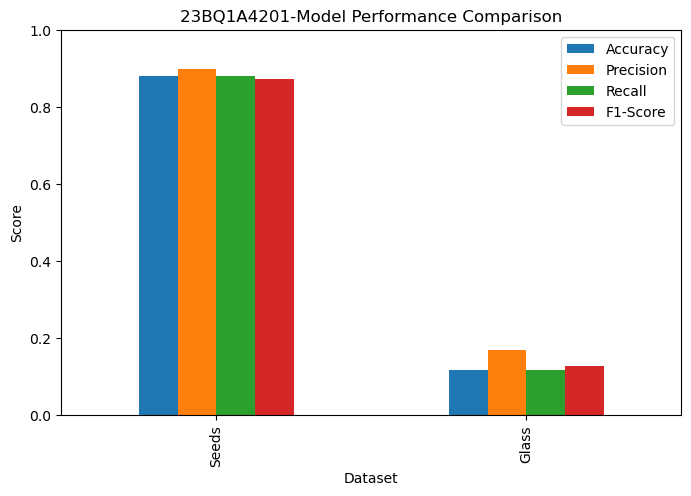

In [30]:
comparison.set_index("Dataset").plot(kind="bar", figsize=(8,5))
plt.title("23BQ1A4201-Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()
